Extracting parameters from C:\Users\mhfar\OneDrive\Desktop\Depo\Code\Neural Engineering\ELE568-Depo\Data\Test3\NS_feltTCRE_BrainAmp_5-2-2025.vhdr...
Setting channel info structure...
Reading 0 ... 1499719  =      0.000 ...  1499.719 secs...

✅ EEG Info:
- Channels: 15
- Duration: 1499.72 sec
- Sampling Rate: 1000.0 Hz

📏 Global Signal STD (µV): 0.0012
Effective window size : 2.048 (s)

⚡ Band Power (total across all channels):
- Delta (0.5–4 Hz): 0.00000205
- Theta (4–8 Hz): 0.00000035
- Alpha (8–12 Hz): 0.00000015
- Beta (12–30 Hz): 0.00000066
- Gamma (30–50 Hz): 0.00000106

📶 SNR (Alpha / Gamma): 0.14


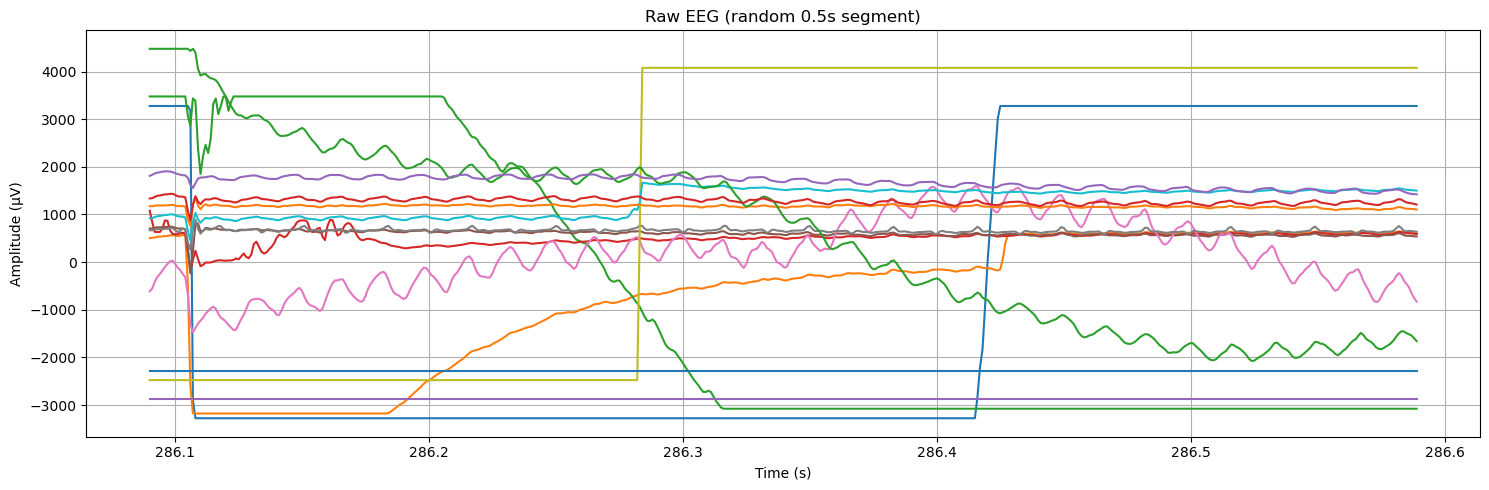

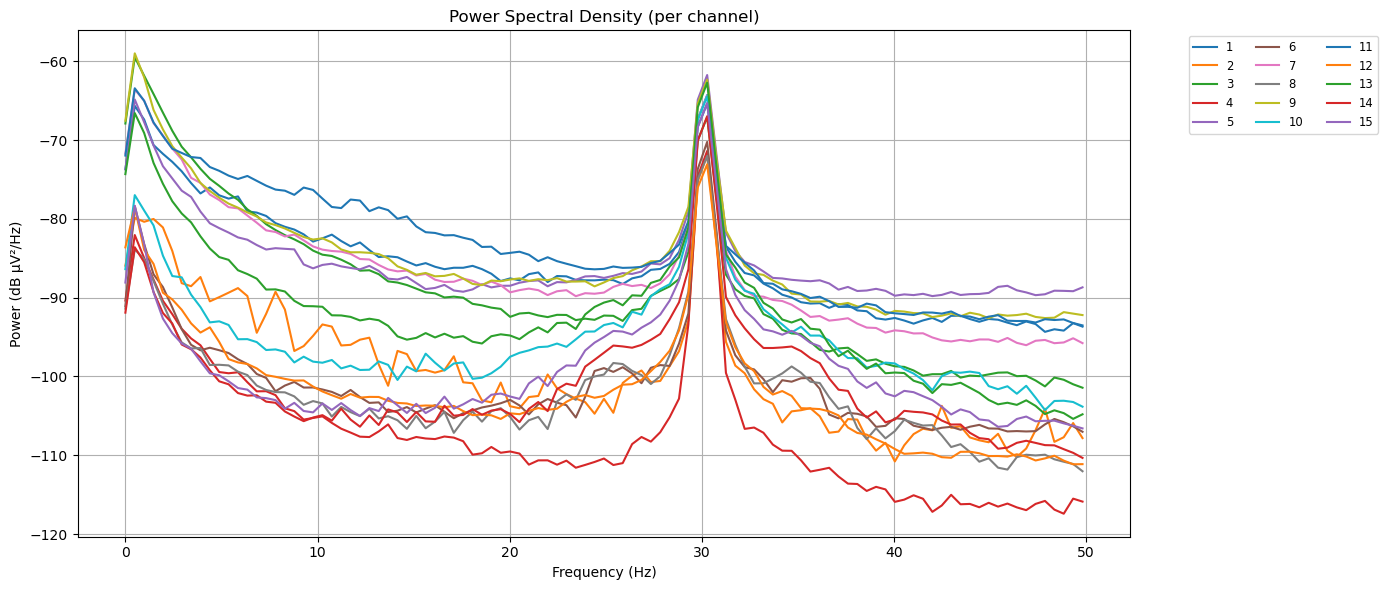

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

# -----------------------------
# Load EEG
# -----------------------------
vhdr_file = r"C:\Users\mhfar\OneDrive\Desktop\Depo\Code\Neural Engineering\ELE568-Depo\Data\Test3\NS_feltTCRE_BrainAmp_5-2-2025.vhdr"
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

# -----------------------------
# Basic Info
# -----------------------------
n_channels = len(raw.ch_names)
duration_sec = raw.times[-1]
sfreq = raw.info['sfreq']
print(f"\n✅ EEG Info:")
print(f"- Channels: {n_channels}")
print(f"- Duration: {duration_sec:.2f} sec")
print(f"- Sampling Rate: {sfreq} Hz")

# -----------------------------
# Global Amplitude / Noise
# -----------------------------
std = raw.get_data().std()
print(f"\n📏 Global Signal STD (µV): {std:.4f}")

# -----------------------------
# PSD Computation
# -----------------------------
psd = raw.compute_psd(fmax=50)
psds, freqs = psd.get_data(return_freqs=True)
psds_db = 10 * np.log10(psds)

# -----------------------------
# Band Power Estimation
# -----------------------------
def bandpower(data, freqs, band):
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return simps(data[:, idx], freqs[idx]).sum()  # total power across all channels

bands = {
    'Delta (0.5–4 Hz)': (0.5, 4),
    'Theta (4–8 Hz)': (4, 8),
    'Alpha (8–12 Hz)': (8, 12),
    'Beta (12–30 Hz)': (12, 30),
    'Gamma (30–50 Hz)': (30, 50)
}

print("\n⚡ Band Power (total across all channels):")
band_powers = {}
for label, band_range in bands.items():
    power = bandpower(psds, freqs, band_range)
    band_powers[label] = power
    print(f"- {label}: {power:.8f}")

# -----------------------------
# SNR: Alpha / Gamma
# -----------------------------
snr = band_powers['Alpha (8–12 Hz)'] / band_powers['Gamma (30–50 Hz)']
print(f"\n📶 SNR (Alpha / Gamma): {snr:.2f}")

# -----------------------------
# Plot 0.5s random raw segment
# -----------------------------
data, times = raw[:n_channels, :]
win = int(sfreq * 0.5)  # half a second
start = np.random.randint(0, data.shape[1] - win)
seg = data[:, start:start+win]
seg_time = times[start:start+win]

offset = 100e-6
plt.figure(figsize=(15, 5))
for i in range(n_channels):
    plt.plot(seg_time, seg[i] * 1e6 + i * offset * 1e6, label=raw.ch_names[i])
plt.title("Raw EEG (random 0.5s segment)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot PSD for each channel
# -----------------------------
plt.figure(figsize=(14, 6))
for i, ch in enumerate(raw.ch_names):
    plt.plot(freqs, psds_db[i], label=ch)
plt.title("Power Spectral Density (per channel)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB µV²/Hz)")
plt.legend(fontsize='small', ncol=3, bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


Extracting parameters from C:\Users\mhfar\OneDrive\Desktop\Depo\Code\Neural Engineering\ELE568-Depo\Data\Test3\NS_feltTCRE_BrainAmp_5-2-2025.vhdr...
Setting channel info structure...
Reading 0 ... 1499719  =      0.000 ...  1499.719 secs...

✅ EEG Info:
- Channels: 15
- Duration: 1499.72 sec
- Sampling Rate: 1000.0 Hz

📏 Global Signal STD (µV): 0.0012
Effective window size : 2.048 (s)

⚡ Band Power (total across all channels):
- Delta (0.5–4 Hz): 0.00000205
- Theta (4–8 Hz): 0.00000035
- Alpha (8–12 Hz): 0.00000015
- Beta (12–30 Hz): 0.00000066
- Gamma (30–50 Hz): 0.00000106

📶 SNR (Alpha / Gamma): 0.14


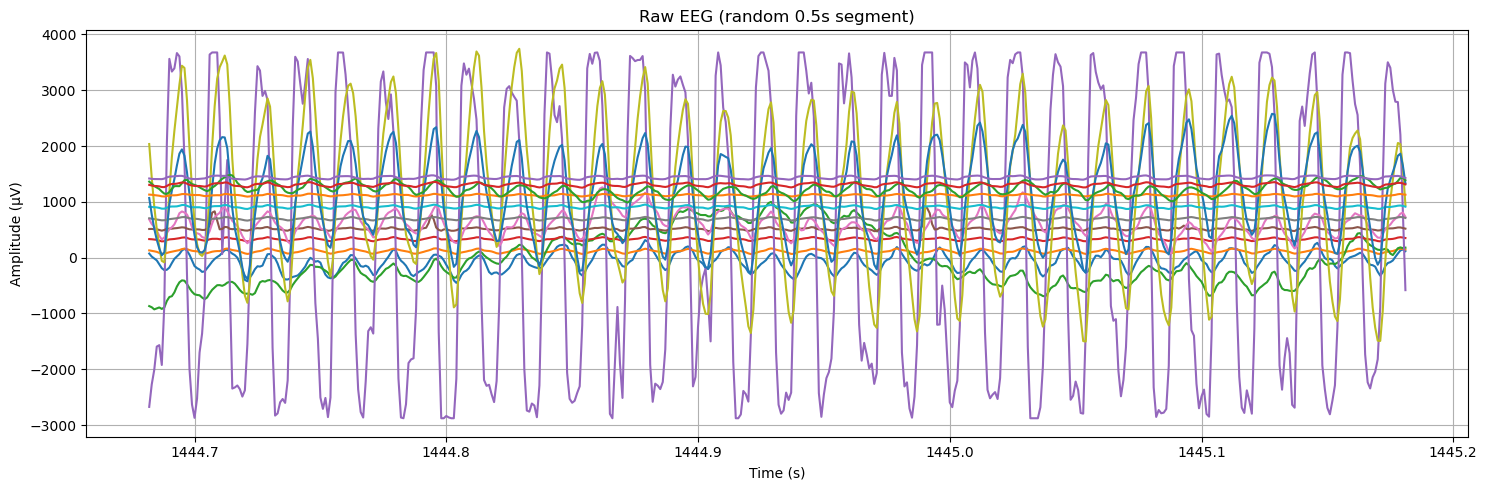

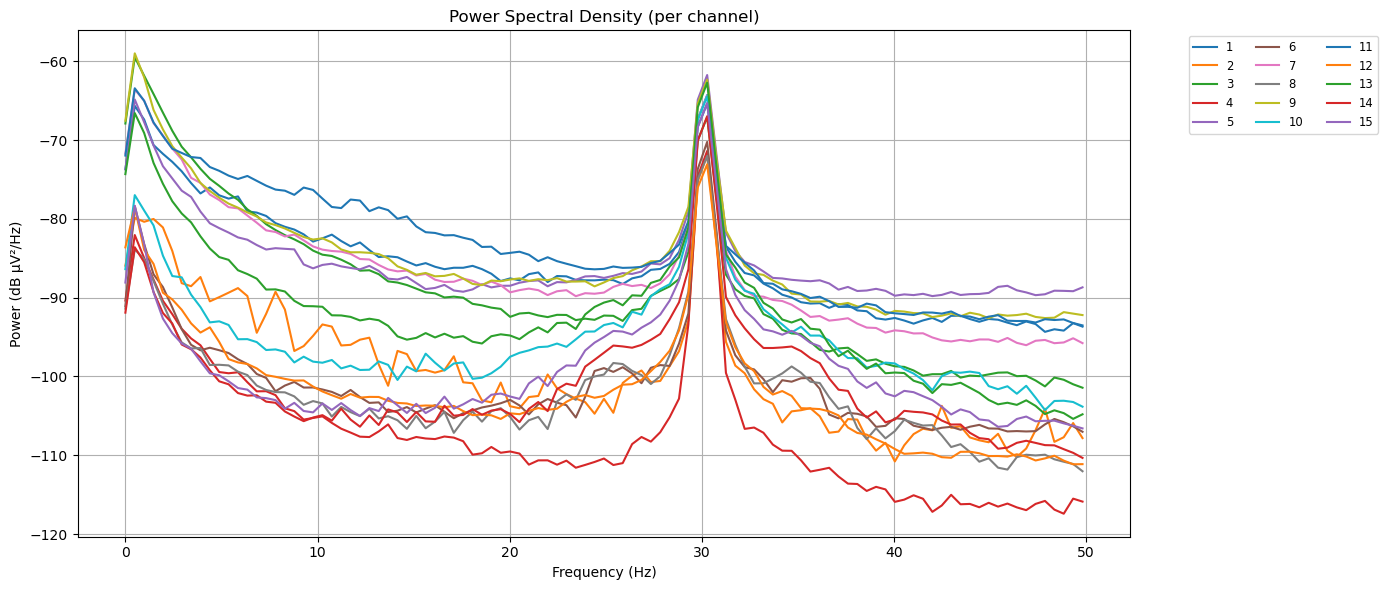

In [3]:
import mne
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simps

# -----------------------------
# Load EEG
# -----------------------------
vhdr_file = r"C:\Users\mhfar\OneDrive\Desktop\Depo\Code\Neural Engineering\ELE568-Depo\Data\Test3\NS_feltTCRE_BrainAmp_5-2-2025.vhdr"
raw = mne.io.read_raw_brainvision(vhdr_file, preload=True)

# -----------------------------
# Basic Info
# -----------------------------
n_channels = len(raw.ch_names)
duration_sec = raw.times[-1]
sfreq = raw.info['sfreq']
print(f"\n✅ EEG Info:")
print(f"- Channels: {n_channels}")
print(f"- Duration: {duration_sec:.2f} sec")
print(f"- Sampling Rate: {sfreq} Hz")

# -----------------------------
# Global Amplitude / Noise
# -----------------------------
std = raw.get_data().std()
print(f"\n📏 Global Signal STD (µV): {std:.4f}")

# -----------------------------
# PSD Computation
# -----------------------------
psd = raw.compute_psd(fmax=50)
psds, freqs = psd.get_data(return_freqs=True)
psds_db = 10 * np.log10(psds)

# -----------------------------
# Band Power Estimation
# -----------------------------
def bandpower(data, freqs, band):
    idx = np.logical_and(freqs >= band[0], freqs <= band[1])
    return simps(data[:, idx], freqs[idx]).sum()  # total power across all channels

bands = {
    'Delta (0.5–4 Hz)': (0.5, 4),
    'Theta (4–8 Hz)': (4, 8),
    'Alpha (8–12 Hz)': (8, 12),
    'Beta (12–30 Hz)': (12, 30),
    'Gamma (30–50 Hz)': (30, 50)
}

print("\n⚡ Band Power (total across all channels):")
band_powers = {}
for label, band_range in bands.items():
    power = bandpower(psds, freqs, band_range)
    band_powers[label] = power
    print(f"- {label}: {power:.8f}")

# -----------------------------
# SNR: Alpha / Gamma
# -----------------------------
snr = band_powers['Alpha (8–12 Hz)'] / band_powers['Gamma (30–50 Hz)']
print(f"\n📶 SNR (Alpha / Gamma): {snr:.2f}")

# -----------------------------
# Plot 0.5s random raw segment
# -----------------------------
data, times = raw[:n_channels, :]
win = int(sfreq * 0.5)  # half a second
start = np.random.randint(0, data.shape[1] - win)
seg = data[:, start:start+win]
seg_time = times[start:start+win]

offset = 100e-6
plt.figure(figsize=(15, 5))
for i in range(n_channels):
    plt.plot(seg_time, seg[i] * 1e6 + i * offset * 1e6, label=raw.ch_names[i])
plt.title("Raw EEG (random 0.5s segment)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot PSD for each channel
# -----------------------------
plt.figure(figsize=(14, 6))
for i, ch in enumerate(raw.ch_names):
    plt.plot(freqs, psds_db[i], label=ch)
plt.title("Power Spectral Density (per channel)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB µV²/Hz)")
plt.legend(fontsize='small', ncol=3, bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
